In [10]:
# Loading data
import pandas as pd
df = pd.read_csv('abcnews_sample.csv')
df.head(3)

,publish_date,headline_text
0,20050627,lawyer claims aust govt has abandoned corby
1,20051206,singapore tells spouses of patients hiv status
2,20141119,iron ore price slumps to new five year low


### Training

In [ ]:
!pip install bertopic

In [11]:
from bertopic import BERTopic
topic_model = BERTopic(
    embedding_model="paraphrase-MiniLM-L3-v2",
    calculate_probabilities=True,
    min_topic_size=10
)

topics, probs = topic_model.fit_transform(df['headline_text'])

### Topic Extraction

In [12]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,8739,-1_to_for_in_of,"[to, for, in, of, on, after, over, the, new, at]","[former qld mps child sex charges dropped, tee..."
1,0,327,0_fire_bushfire_firefighters_fires,"[fire, bushfire, firefighters, fires, bushfire...","[firefighters save homes during blaze, queensl..."
2,1,277,1_water_dam_river_lake,"[water, dam, river, lake, basin, pool, authori...","[residents warned of water bill changes, indig..."
3,2,258,2_iraq_baghdad_afghan_kills,"[iraq, baghdad, afghan, kills, iraqi, bomb, ta...","[afghan suicide blast kills 15 civilians nato,..."
4,3,211,3_interview_extended_brett_nathan,"[interview, extended, brett, nathan, ivan, and...","[will martin interview, interview brett white,..."
...,...,...,...,...,...
305,304,10,304_pub_pooseum_quoll_outhouse,"[pub, pooseum, quoll, outhouse, balldale, util...",[revival of small town pub in balldale victori...
306,305,10,305_plus_one_friday_marree,"[plus, one, friday, marree, montaigne, sarra, ...","[one plus one friday 25 march, one plus one fr..."
307,306,10,306_refugees_refugee_dili_biometric,"[refugees, refugee, dili, biometric, ossetia, ...","[darwin refugees in asio limbo, biometric data..."
308,307,10,307_weather_quarter_perfectly_tpc,"[weather, quarter, perfectly, tpc, forecasts, ...","[friday weather, the weather quarter, the weat..."


In [13]:
# Number of topics
len(topic_model.get_topic_info())

310

In [14]:
# Get first topic words and thier TF-IDF scores
first_topic = topic_model.get_topic(0)
first_topic

[('fire', np.float64(0.06805369964480577)),
 ('bushfire', np.float64(0.05469492751720655)),
 ('firefighters', np.float64(0.03629732578652069)),
 ('fires', np.float64(0.026083992608088587)),
 ('bushfires', np.float64(0.024136231587875756)),
 ('crews', np.float64(0.023161041264458716)),
 ('homes', np.float64(0.019112495148887423)),
 ('burning', np.float64(0.017553478503255667)),
 ('blaze', np.float64(0.013579679651182857)),
 ('fireworks', np.float64(0.01318719650811694))]

### Topics Visualization

In [15]:
# Topic terms barchart
topic_model.visualize_barchart(top_n_topics=10)

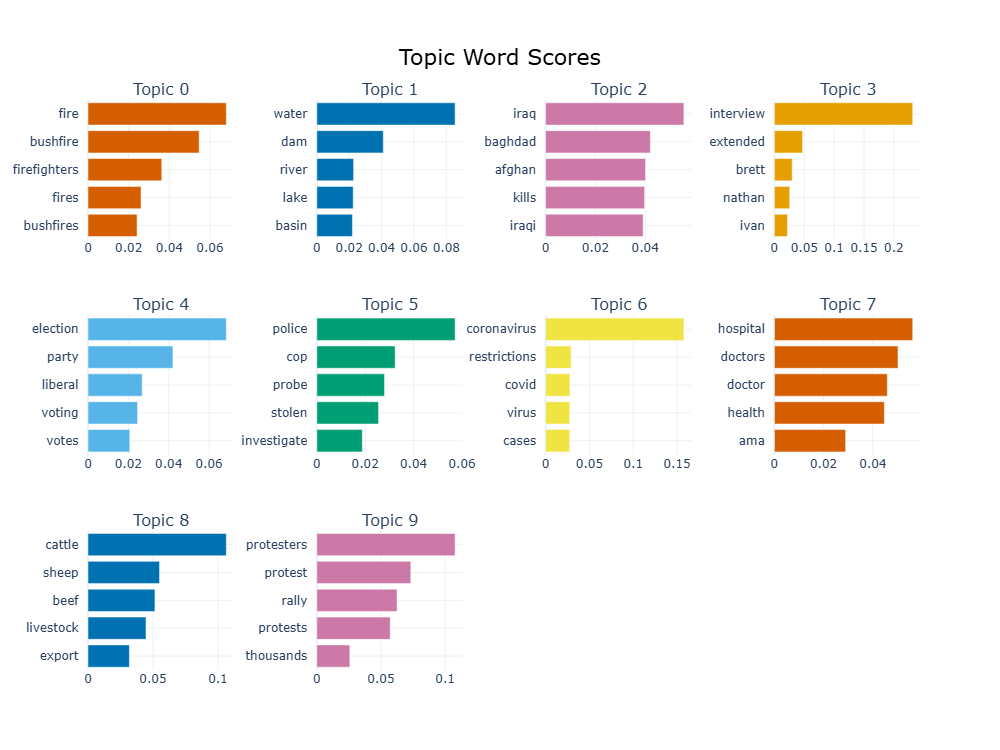

In [16]:
# Intertopic distance map
topic_model.visualize_topics()

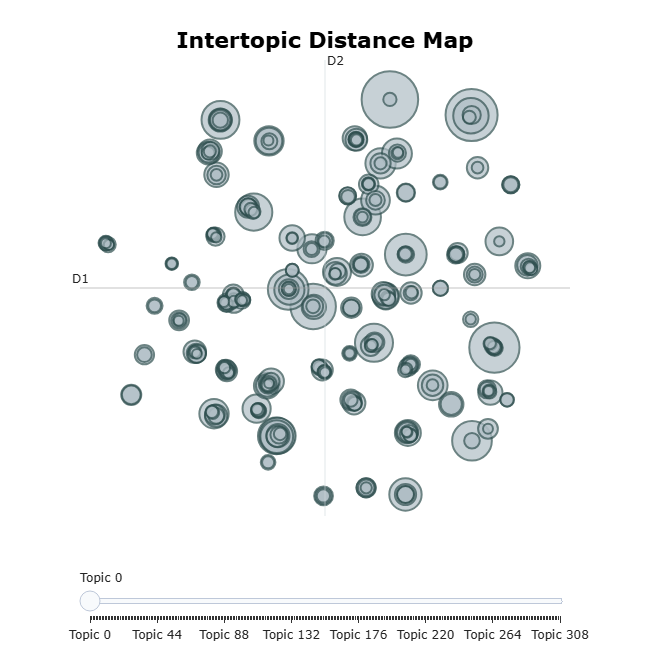

In [17]:
# Topic Hierarchy
topic_model.visualize_hierarchy(top_n_topics=30)

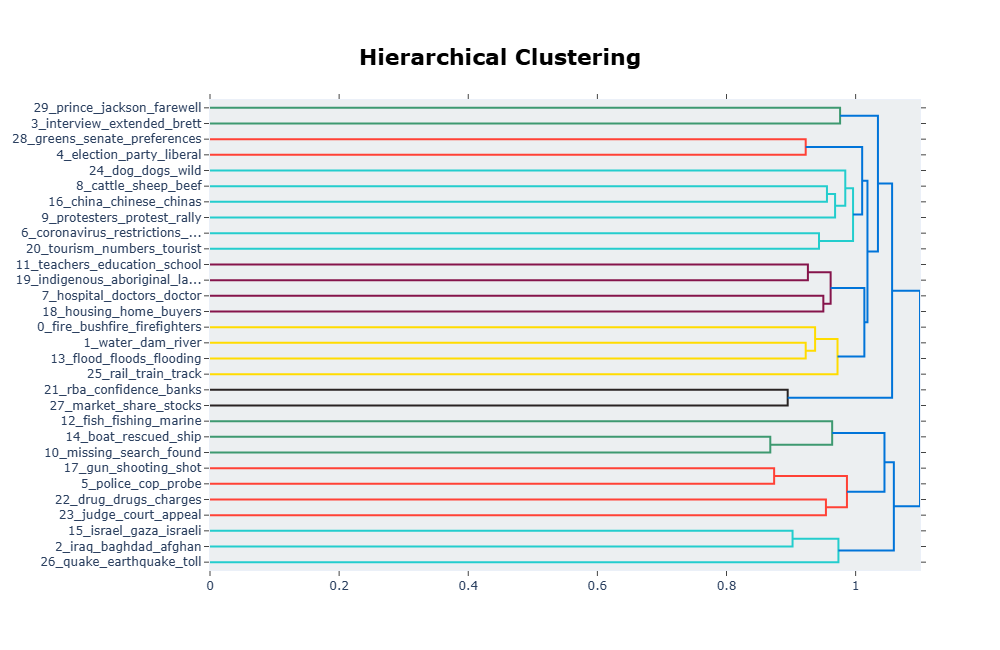

### Search topics

In [24]:
similar_topics, similarity = topic_model.find_topics("election", top_n=3)
similar_topics, similarity

([4, 160, 151],
 [np.float32(0.7865409), np.float32(0.4683358), np.float32(0.38794935)])

In [21]:
topic_model.get_topic(4)

[('election', np.float64(0.06854136998243408)),
 ('party', np.float64(0.042080115039918556)),
 ('liberal', np.float64(0.026841092853975887)),
 ('voting', np.float64(0.024587662054561383)),
 ('votes', np.float64(0.020714675414915805)),
 ('politics', np.float64(0.019552054038454714)),
 ('voters', np.float64(0.019039369806398723)),
 ('counting', np.float64(0.01786062913592241)),
 ('candidates', np.float64(0.017623282211286298)),
 ('vote', np.float64(0.01688591242819254))]

In [22]:
similarity[0]

np.float32(0.7865409)

In [23]:
topic_model.get_topic(160)

[('clinton', np.float64(0.1779219157517818)),
 ('romney', np.float64(0.1038530240488757)),
 ('republican', np.float64(0.10015070780168546)),
 ('presidential', np.float64(0.08364312825924029)),
 ('hillary', np.float64(0.08118172438924716)),
 ('obama', np.float64(0.06245229424374684)),
 ('biden', np.float64(0.048475582982799206)),
 ('trump', np.float64(0.04266341109290876)),
 ('debate', np.float64(0.04058738662906012)),
 ('hamad', np.float64(0.036816286097086204))]

In [25]:
similarity[1]

np.float32(0.4683358)

In [26]:
topic_model.get_topic(151)

[('mayor', np.float64(0.2625617819404993)),
 ('lord', np.float64(0.05129029425276819)),
 ('stands', np.float64(0.0392255093593774)),
 ('alexandrina', np.float64(0.03895400593498153)),
 ('arrange', np.float64(0.03895400593498153)),
 ('damned', np.float64(0.03895400593498153)),
 ('diamantina', np.float64(0.03895400593498153)),
 ('mchugh', np.float64(0.03895400593498153)),
 ('vline', np.float64(0.03895400593498153)),
 ('kym', np.float64(0.03895400593498153))]

In [27]:
similarity[2]

np.float32(0.38794935)

### Saving model

In [28]:
topic_model.save("news_topic_model")

2026-01-04 07:44:10,402 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [30]:
news_model = BERTopic.load("news_topic_model")
news_model